In [ ]:
# # =========================
# # Batch pipeline (switch OFF by default)
# # 4 students x 2 days x 5 actions x 5 models = 200 tasks
# # =========================

# from pathlib import Path
# import re
# import json
# import pandas as pd

# # ---- master switch ----
# RUN_BATCH = False  # Keep False for now. Set True when you are ready.

# PROJECT_ROOT = Path('/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT')
# CSV_DIR = PROJECT_ROOT / 'study-data-per-student-day-behavior'
# OUTPUT_ROOT = PROJECT_ROOT / 'batch-results'

# ACTION_PROMPTS = {
#     'enacting': PROJECT_ROOT / 'Prompt_ENACTING.txt',
#     'interacting': PROJECT_ROOT / 'Prompt_INTERACTING.txt',
#     'monitoring': PROJECT_ROOT / 'Prompt_MONITORING.txt',
#     'planning': PROJECT_ROOT / 'Prompt_PLANNING.txt',
#     'reflecting': PROJECT_ROOT / 'Prompt_REFLECTING.txt',
# }

# MODEL_SET = [
#     {'model_id': 'o3', 'model_alias': 'o3', 'max_tokens': 8000},
#     {'model_id': 'gpt-4o', 'model_alias': 'ChatGPT_4', 'max_tokens': 32000},
#     {'model_id': 'gpt-5.2', 'model_alias': 'ChatGPT_5_2', 'max_tokens': 8000},
#     {'model_id': 'us.anthropic.claude-haiku-4-5-20251001-v1:0', 'model_alias': 'Claude_haiku_4_5', 'max_tokens': 32000},
#     {'model_id': 'us.anthropic.claude-sonnet-4-5-20250929-v1:0', 'model_alias': 'Claude_sonnet_4_5', 'max_tokens': 32000},
# ]

# FILE_RE = re.compile(
#     r'^L&I - embodied - Student (?P<student>.+?) - day (?P<day>[12]) - (?P<action>enacting|interacting|monitoring|planning|reflecting)\\.csv$'
# )


# def _slug(s: str) -> str:
#     return re.sub(r'[^a-zA-Z0-9]+', '_', s).strip('_')


# def load_prompt_messages(prompt_path: Path):
#     split_marker = '\n[***NEW_MESSAGE***]\n'
#     text = prompt_path.read_text(encoding='utf-8')
#     parts = text.split(split_marker)
#     if len(parts) != 3:
#         raise ValueError(f'Prompt format invalid: {prompt_path}')
#     return [
#         {'role': 'system', 'content': parts[0].strip()},
#         {'role': 'user', 'content': parts[1].strip()},
#         {'role': 'assistant', 'content': parts[2].strip()},
#     ]


# def build_task_matrix():
#     tasks = []
#     for csv_path in sorted(CSV_DIR.glob('*.csv')):
#         m = FILE_RE.match(csv_path.name)
#         if not m:
#             continue
#         student = m.group('student')
#         day = m.group('day')
#         action = m.group('action')
#         prompt_path = ACTION_PROMPTS[action]

#         for model in MODEL_SET:
#             out_dir = OUTPUT_ROOT / action / f"{_slug(student)}_day{day}"
#             out_json = out_dir / f"{model['model_alias']}.json"
#             tasks.append({
#                 'student': student,
#                 'day': day,
#                 'action': action,
#                 'csv_path': str(csv_path),
#                 'prompt_path': str(prompt_path),
#                 'model_id': model['model_id'],
#                 'model_alias': model['model_alias'],
#                 'max_tokens': model['max_tokens'],
#                 'output_json_path': str(out_json),
#             })

#     expected = 4 * 2 * 5 * 5
#     print('Built tasks:', len(tasks), '| expected:', expected)
#     if len(tasks) != expected:
#         raise RuntimeError(f'Task count mismatch: got {len(tasks)}, expected {expected}')

#     return tasks


# # 1) Always build and save manifest first (safe stage)
# TASKS = build_task_matrix()
# manifest_json = PROJECT_ROOT / 'batch_task_manifest.json'
# manifest_csv = PROJECT_ROOT / 'batch_task_manifest.csv'

# manifest_json.write_text(json.dumps(TASKS, indent=2, ensure_ascii=False), encoding='utf-8')
# pd.DataFrame(TASKS).to_csv(manifest_csv, index=False)

# print('Manifest JSON:', manifest_json)
# print('Manifest CSV :', manifest_csv)
# print('RUN_BATCH    :', RUN_BATCH)


# # 2) Batch execution (OFF by default)
# # Requires existing globals from your notebook:
# # - run_pipeline(...)
# # - get_available_models(...)
# # - BASE_URL
# # - headers
# if RUN_BATCH:
#     available_model_ids, _default_model_id, _payload, available_model_lookup = get_available_models(BASE_URL, headers)
#     offered_ids = {m.lower().strip() for m in available_model_ids if isinstance(m, str)}

#     reports = []
#     for t in TASKS:
#         model_id = t['model_id']
#         if model_id.lower().strip() not in offered_ids:
#             reports.append({**t, 'status': 'skipped_model_not_offered'})
#             continue

#         out_path = Path(t['output_json_path'])
#         if out_path.exists():
#             reports.append({**t, 'status': 'skipped_exists'})
#             continue
#         out_path.parent.mkdir(parents=True, exist_ok=True)

#         # prompt messages
#         msg = load_prompt_messages(Path(t['prompt_path']))

#         # csv as final user message
#         df_local = pd.read_csv(t['csv_path']).fillna('')
#         if 'data' in df_local.columns:
#             df_local['data'] = df_local['data'].replace('not moving', 'stationary')
#         csv_text = df_local.to_csv(index=False)

#         messages_local = msg + [{'role': 'user', 'content': csv_text}]

#         try:
#             r = run_pipeline(
#                 model_id=model_id,
#                 messages=messages_local,
#                 base_url=BASE_URL,
#                 headers=headers,
#                 output_dir=str(out_path.parent),
#                 output_stem=out_path.stem,
#                 max_tokens=t['max_tokens'],
#                 temperature=0,
#                 max_attempts=5,
#                 strict_mode=True,
#                 segments_only=True,
#                 allow_salvage=True,
#                 model_object=available_model_lookup.get(model_id),
#             )
#             reports.append({**t, 'status': 'success', 'segment_count': r.get('segment_count')})
#         except Exception as e:
#             reports.append({**t, 'status': 'failed', 'error': str(e)})

#     report_path = PROJECT_ROOT / 'batch_run_report.json'
#     report_path.write_text(json.dumps(reports, indent=2, ensure_ascii=False), encoding='utf-8')
#     print('Saved run report:', report_path)
# else:
#     print('Batch execution is OFF. Only task manifest generated.')

Load and Format Prompt

In [ ]:
# available models
import requests
import os

# Paste Amplify token between the quotes 
os.environ["AMP_TOKEN"] = ""

url = "https://prod2-api.vanderbilt.ai"
_tok = os.environ.get("AMP_TOKEN", "").strip()
if not _tok:
    raise RuntimeError("Fill os.environ['AMP_TOKEN'] above with your token.")
headers = {
    "Authorization": f"Bearer {_tok}",
    "Content-Type": "application/json",
}

response = requests.get(url, headers=headers, timeout=30)
print("Status:", response.status_code)

if response.status_code == 200:
    payload = response.json()
    models = payload.get("data", {}).get("models", [])
    print("Model count:", len(models))
else:
    print(response.text[:500])

Status: 403
{"message":"Invalid key=value pair (missing equal-sign) in Authorization header (hashed with SHA-256 and encoded with Base64): 'm4NOWvaIsdNdo+7kVtYhNsYU2YC++A+fQGbkVgRgE/M='."}


In [20]:
PROMPT_PATH = "Prompt_ENACTING.txt"
with open(PROMPT_PATH, "r") as file:
    prompt_raw = file.read()

In [21]:
# Used to separate system message 
SPLIT_STRING = "\n[***NEW_MESSAGE***]\n"

# Split the raw prompt text into 3 sections
prompt_split = prompt_raw.split(SPLIT_STRING)

# Ensure the prompt file format is correct
assert len(prompt_split) == 3, "Prompt file format incorrect."

In [22]:
# Convert prompt components to Amplify message format(json)
messages = [
    {"role": "system", "content": prompt_split[0].strip()},
    {"role": "user", "content": prompt_split[1].strip()},
    {"role": "assistant", "content": prompt_split[2].strip()}
]

# (Optional)Print to verify structure
for m in messages:
    print(m)


{'role': 'system', 'content': 'You are a helpful research assistant whose job it is to identify segments of students\' self-regulated learning (SRL) behaviors using multimodal data of them interacting with a mixed-reality embodied learning environment. Specifically, your job is to identify segments where students are demonstrating the ENACTING behavior.\n\nThis work focuses on the photosynthesis model. Participants\' movements are displayed on a projector screen while students embody different molecules as they move around the classroom. The environment features a mouse and a tomato plant with zoomed-in chloroplasts and roots (areas that cause molecule transformations). Students must move towards these areas to model interactions between the molecules they are embodying (oxygen, water, water-thinking, sugar and carbon dioxide) and the features on the screen. As students move, their states change, and they learn about the process of photosynthesis.\n\nFor example, one student may be ass

Import data

In [23]:
import pandas as pd

DATA_PATH = "L&I - Student Mastersheet - EN-MESSI-D2.csv"

df = pd.read_csv(DATA_PATH)

# Convert all the NaN to the ''
df = df.fillna('')

# Convert instances of "not moving" to "stationary"
df["data"] = df["data"].replace("not moving", "stationary")

df.head()

,start_time,end_time,modality,data
0,0:00:00,,state,waterthinking
1,0:00:00,0:00:05,movement,stationary
2,0:00:00,0:00:01,gaze,Student - Taylor Swift
3,0:00:06,0:00:09,movement,moving
4,0:00:07,0:04:38,gaze,Screen


In [24]:
# Filter dataframe where:
# 1. "modality" does not include gesture or speech
# 2. "gaze" only includes Screen
df_no_speech_or_gaze = df[~df["modality"].isin(["gesture", "speech"])]
assert set(df_no_speech_or_gaze.modality) == {'state', 'movement', 'action', 'gaze'}

df_no_speech_or_gaze_screen_only = df_no_speech_or_gaze[(df_no_speech_or_gaze["modality"] != "gaze") | \
        (df_no_speech_or_gaze["data"] == "Screen")]
assert all(df_no_speech_or_gaze_screen_only[df_no_speech_or_gaze_screen_only["modality"] == \
                                            "gaze"]["data"] == "Screen")
df_no_speech_or_gaze_screen_only.head(5)

,start_time,end_time,modality,data
0,0:00:00,,state,waterthinking
1,0:00:00,0:00:05,movement,stationary
3,0:00:06,0:00:09,movement,moving
4,0:00:07,0:04:38,gaze,Screen
5,0:00:08,0:00:14,movement,stationary


In [25]:
# Make data comma-separated form but in string
data_csv_string = df_no_speech_or_gaze_screen_only.to_csv(index=False)

data_csv_string_split = [s for s in data_csv_string.split('\n') if s]
assert len(data_csv_string_split) == len(df_no_speech_or_gaze_screen_only)+1,print(len(data_csv_string_split), len(df_no_speech_or_gaze_screen_only)+1)

In [26]:
# Rebuild messages cleanly every time

messages = [
    {"role": "system", "content": prompt_split[0].strip()},
    {"role": "user", "content": prompt_split[1].strip()},
    {"role": "assistant", "content": prompt_split[2].strip()},
    {"role": "user", "content": data_csv_string}
]

print("Message length:", len(messages))


Message length: 4


In [27]:
## Configuration
import os
BASE_URL = "https://prod-api.vanderbilt.ai"
AMP_TOKEN = os.environ.get("AMP_TOKEN", "").strip()
if not AMP_TOKEN:
    raise RuntimeError("Set AMP_TOKEN environment variable.")

headers = {
    "Authorization": f"Bearer {AMP_TOKEN}",
    "Content-Type": "application/json",
}

print("Config ready for pipeline.")

Config ready for pipeline.


In [29]:

if "run_pipeline" in globals() and "_run_pipeline_original" not in globals():
    _run_pipeline_original = run_pipeline


def safe_parse_json(text):
    # Already-structured payload from provider.
    if isinstance(text, (dict, list)):
        return text
    if not isinstance(text, str):
        return None

    s = _unwrap_code_fence(text).strip()

    # 1) Exact JSON.
    try:
        return json.loads(s)
    except Exception:
        pass

    # 2) First valid JSON value (allows trailing prose).
    try:
        decoder = json.JSONDecoder()
        obj, _ = decoder.raw_decode(s)
        return obj
    except Exception:
        pass

    # 3) Fallback object/array span.
    for pat in (r"\{[\s\S]*\}", r"\[[\s\S]*\]"):
        m = re.search(pat, s)
        if not m:
            continue
        cand = m.group(0).strip()
        try:
            return json.loads(cand)
        except Exception:
            try:
                obj, _ = json.JSONDecoder().raw_decode(cand)
                return obj
            except Exception:
                pass

    return None


def run_pipeline(model_id: str, messages: list, base_url: str, headers: dict,
                 output_dir: str = ".", output_stem: str | None = None,
                 max_tokens: int = 4000, temperature: float = 0,
                 max_attempts: int = 3, strict_mode: bool = True,
                 segments_only: bool = True,
                 model_object: dict | None = None):

    if "_run_pipeline_original" not in globals():
        raise RuntimeError("Hotfix loaded before base pipeline. Run the 'Unified Inference Pipeline' cell first, then rerun this hotfix cell.")

    if isinstance(model_id, str) and "gpt-4o" in model_id.lower():
        max_tokens = max(int(max_tokens), 12000)

    try:
        return _run_pipeline_original(
            model_id=model_id,
            messages=messages,
            base_url=base_url,
            headers=headers,
            output_dir=output_dir,
            output_stem=output_stem,
            max_tokens=max_tokens,
            temperature=temperature,
            max_attempts=max_attempts,
            strict_mode=strict_mode,
            segments_only=segments_only,
            model_object=model_object,
        )
    except RuntimeError as e:
        msg = str(e)
        if strict_mode and "Strict mode: invalid JSON" in msg and isinstance(model_id, str) and "gpt-4o" in model_id.lower():
            # One larger-budget retry before failing.
            retry_tokens = max(int(max_tokens) * 2, 16000)
            return _run_pipeline_original(
                model_id=model_id,
                messages=messages,
                base_url=base_url,
                headers=headers,
                output_dir=output_dir,
                output_stem=output_stem,
                max_tokens=retry_tokens,
                temperature=temperature,
                max_attempts=max_attempts,
                strict_mode=strict_mode,
                segments_only=segments_only,
                model_object=model_object,
            )
        raise


print("Hotfix loaded: robust JSON parse + gpt-4o higher token budget")

Hotfix loaded: robust JSON parse + gpt-4o higher token budget


In [30]:
# ===== Unified Inference Pipeline =====
import os
import re
import json
import requests
import pandas as pd


def get_available_models(base_url: str, headers: dict):
    url = f"{base_url}/available_models"
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    payload = r.json()

    data = payload.get("data", {}) if isinstance(payload, dict) else {}
    models = data.get("models", []) if isinstance(data, dict) else []
    default_model = data.get("default", {}) if isinstance(data, dict) else {}

    model_ids = [m.get("id") for m in models if isinstance(m, dict) and isinstance(m.get("id"), str)]
    model_ids = list(dict.fromkeys(model_ids))
    default_id = default_model.get("id") if isinstance(default_model, dict) else None

    model_lookup = {
        m.get("id"): m for m in models
        if isinstance(m, dict) and isinstance(m.get("id"), str)
    }
    return model_ids, default_id, payload, model_lookup


def _unwrap_code_fence(text: str) -> str:
    s = text.strip()
    m = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", s, re.IGNORECASE)
    return m.group(1).strip() if m else s


def _parse_time_to_seconds(time_str: str):
    if not isinstance(time_str, str):
        return None
    s = time_str.strip()
    if not s:
        return None

    parts = s.split(":")
    try:
        if len(parts) == 3:
            h, m, sec = parts
            return int(h) * 3600 + int(m) * 60 + float(sec)
        if len(parts) == 2:
            m, sec = parts
            return int(m) * 60 + float(sec)
    except ValueError:
        return None
    return None


def _seconds_to_hhmmss(seconds: float) -> str:
    total = max(0, int(round(seconds)))
    h = total // 3600
    m = (total % 3600) // 60
    s = total % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


def _normalize_time_text(time_str: str) -> str | None:
    sec = _parse_time_to_seconds(time_str)
    if sec is None:
        return None
    return _seconds_to_hhmmss(sec)


def safe_parse_json(text):
    # Already-structured payload from provider.
    if isinstance(text, (dict, list)):
        return text

    if not isinstance(text, str):
        return None

    s = _unwrap_code_fence(text).strip()

    # 1) Exact JSON.
    try:
        return json.loads(s)
    except Exception:
        pass

    # 2) First valid JSON value (allows trailing text).
    try:
        decoder = json.JSONDecoder()
        obj, _ = decoder.raw_decode(s)
        return obj
    except Exception:
        pass

    # 3) Fallback object/array span parse.
    for pat in (r"\{[\s\S]*\}", r"\[[\s\S]*\]"):
        m = re.search(pat, s)
        if not m:
            continue
        cand = m.group(0).strip()
        try:
            return json.loads(cand)
        except Exception:
            try:
                obj, _ = json.JSONDecoder().raw_decode(cand)
                return obj
            except Exception:
                pass

    return None


def normalize_output_data(data):
    """Normalize provider payload into (parsed_json_or_none, error_message_or_none, raw_text)."""
    if isinstance(data, dict):
        # Backend may wrap error in structured dict/list; coerce safely to text.
        err = data.get("error") or data.get("message")
        if err is not None:
            err_text = str(err).strip()
            if err_text:
                return None, err_text, json.dumps(data, ensure_ascii=False)
        return data, None, json.dumps(data, ensure_ascii=False)

    if isinstance(data, list):
        if len(data) == 0:
            return None, "Empty list response", "[]"
        return data, None, json.dumps(data, ensure_ascii=False)

    if isinstance(data, str):
        s = data.strip()
        if not s:
            return None, "Empty string response", ""
        if s.lower().startswith("error:"):
            return None, s, s
        parsed = safe_parse_json(s)
        return parsed, None if parsed is not None else None, s

    return None, f"Unsupported response type: {type(data).__name__}", str(data)



def salvage_segments(text: str):
    if not isinstance(text, str):
        return []

    s = _unwrap_code_fence(text)
    pattern = re.compile(
        r'\{[^{}]*?"justification"\s*:\s*"(?P<just>(?:\\.|[^"\\])*)"\s*,\s*'
        r'"time_in"\s*:\s*"(?P<time_in>[^"]*)"\s*,\s*'
        r'"time_out"\s*:\s*"(?P<time_out>[^"]*)"\s*,\s*'
        r'"label"\s*:\s*"(?P<label>[^"]*)"\s*\}',
        re.DOTALL,
    )

    segments = []
    for m in pattern.finditer(s):
        segments.append({
            "justification": m.group("just").replace('\\"', '"').replace("\\n", "\n"),
            "time_in": m.group("time_in"),
            "time_out": m.group("time_out"),
            "label": m.group("label"),
        })
    return segments


def _extract_screen_gaze_windows_from_csv(csv_text: str):
    df_local = pd.read_csv(pd.io.common.StringIO(csv_text)).fillna("")
    df_local["modality"] = df_local["modality"].astype(str)
    df_local["data"] = df_local["data"].astype(str)

    gaze = df_local[(df_local["modality"] == "gaze") & (df_local["data"] == "Screen")]
    windows = []
    for _, r in gaze.iterrows():
        s = _parse_time_to_seconds(str(r.get("start_time", "")))
        e = _parse_time_to_seconds(str(r.get("end_time", "")))
        if s is None or e is None or e <= s:
            continue
        windows.append((s, e))
    return windows


def normalize_and_validate_segments(segments: list, csv_text: str):
    # Conservative validation: keep semantics, enforce valid spans, remove exact duplicates.
    if not isinstance(segments, list):
        return []

    out = []
    seen = set()

    for seg in segments:
        if not isinstance(seg, dict):
            continue

        s = _parse_time_to_seconds(str(seg.get("time_in", "")))
        e = _parse_time_to_seconds(str(seg.get("time_out", "")))
        if s is None or e is None or e <= s:
            continue

        row = {
            "justification": str(seg.get("justification", "")).strip(),
            "time_in": _seconds_to_hhmmss(s),
            "time_out": _seconds_to_hhmmss(e),
            "label": str(seg.get("label", "ENACTING") or "ENACTING"),
        }

        # Exact duplicate suppression only.
        dedup_key = (row["justification"], row["time_in"], row["time_out"], row["label"])
        if dedup_key in seen:
            continue
        seen.add(dedup_key)

        out.append(row)

    out.sort(key=lambda x: (
        _parse_time_to_seconds(x.get("time_in", "")),
        _parse_time_to_seconds(x.get("time_out", "")),
    ))
    return out


def compact_segment_text(segments: list, max_words: int = 12, max_chars: int = 90):
    """Hard-cap justification verbosity to keep model outputs compact and stable."""
    if not isinstance(segments, list):
        return []

    compacted = []
    for seg in segments:
        if not isinstance(seg, dict):
            continue

        j = str(seg.get("justification", "")).strip()
        if not j:
            j = "Verified event"

        # Keep only the first sentence-like chunk.
        j = re.split(r"(?<=[.!?])\s+", j)[0].strip()

        # Enforce short text budget.
        words = j.split()
        if len(words) > max_words:
            j = " ".join(words[:max_words])
        if len(j) > max_chars:
            j = j[:max_chars].rstrip()

        compacted.append({
            "justification": j,
            "time_in": seg.get("time_in", ""),
            "time_out": seg.get("time_out", ""),
            "label": seg.get("label", "ENACTING"),
        })

    return compacted


def sanitize_filename(text: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]", "_", text)


def run_pipeline(model_id: str, messages: list, base_url: str, headers: dict,
                 output_dir: str = ".", output_stem: str | None = None,
                 max_tokens: int = 4000, temperature: float = 0,
                 max_attempts: int = 3, strict_mode: bool = True,
                 segments_only: bool = True,
                 allow_salvage: bool = False,
                 model_object: dict | None = None):

    def prepare_messages_for_model(model_id_inner: str, msg_list: list):
        # Many providers are more stable without prefilled assistant exemplar turns.
        m = model_id_inner.lower()
        if ("anthropic" in m or "claude" in m):
            return [x for x in msg_list if x.get("role") != "assistant"]
        return msg_list

    def coerce_messages_to_text(msg_list: list):
        out = []
        for item in msg_list:
            role = str(item.get("role", "user"))
            content = item.get("content", "")
            if isinstance(content, str):
                text = content
            elif isinstance(content, (dict, list)):
                text = json.dumps(content, ensure_ascii=False)
            else:
                text = str(content)
            out.append({"role": role, "content": text})
        return out

    model_messages = coerce_messages_to_text(prepare_messages_for_model(model_id, messages))

    csv_text = ""
    for m in reversed(model_messages):
        if m.get("role") == "user" and "start_time" in str(m.get("content", "")):
            csv_text = str(m.get("content", ""))
            break

    tag = sanitize_filename(model_id)
    stem = (output_stem or f"MESSI_ENACT_{tag}").strip()
    json_path = os.path.join(output_dir, f"{stem}.json")

    # Token budgets: retry with larger budgets to reduce mid-JSON truncation.
    if "anthropic" in model_id.lower() or "claude" in model_id.lower():
        cap = min(max_tokens, 32000)
        token_schedule = [cap, max(int(cap * 0.75), 4000), max(int(cap * 0.5), 3000)]
    else:
        # Non-Claude schedule must be non-decreasing to avoid regression retries.
        base = max(12000, int(max_tokens))
        token_schedule = [
            base,
            min(max(base, 16000), 24000),
            min(max(base * 2, 24000), 32000),
            32000,
        ]

    payload = {
        "data": {
            "temperature": temperature,
            "max_tokens": token_schedule[0],
            "dataSources": [],
            "messages": model_messages,
            "response_format": {"type": "json_object"},
            "options": {
                "skipRag": True,
                "ragOnly": False,
                "model": model_object if isinstance(model_object, dict) else {"id": model_id},
            },
        }
    }

    last_error = None
    used_model_object_fallback = isinstance(model_object, dict)
    for attempt in range(1, max_attempts + 1):
        token_idx = min(attempt - 1, len(token_schedule) - 1)
        payload["data"]["max_tokens"] = token_schedule[token_idx]

        response = requests.post(f"{base_url}/chat", headers=headers, json=payload, timeout=300)
        if response.status_code >= 400:
            body_text = response.text[:1000]
            print(f"[attempt {attempt}] HTTP {response.status_code} body:", body_text)
            if (not used_model_object_fallback) and response.status_code == 400:
                payload["data"]["options"]["model"] = {"id": model_id}
                used_model_object_fallback = True
                print(f"[attempt {attempt}] HTTP 400 -> switching model field to object fallback")
                continue
            last_error = RuntimeError(f"HTTP {response.status_code}: {body_text}")
            continue

        result = response.json()

        print(f"[attempt {attempt}] max_tokens:", payload["data"]["max_tokens"])
        print(f"[attempt {attempt}] message_count:", len(payload["data"]["messages"]))
        print(f"[attempt {attempt}] result keys:", list(result.keys()) if isinstance(result, dict) else type(result).__name__)
        print(f"[attempt {attempt}] result.success:", result.get("success") if isinstance(result, dict) else None)
        print(f"[attempt {attempt}] repr(result.data):", repr(result.get("data")) if isinstance(result, dict) else None)

        if not isinstance(result, dict) or not result.get("success"):
            last_error = RuntimeError(f"Amplify returned failure: {result}")
            continue

        raw_data = result.get("data", "")
        if isinstance(raw_data, (dict, list)):
            raw_text = json.dumps(raw_data, ensure_ascii=False)
        else:
            raw_text = str(raw_data).strip()

        if not raw_text:
            last_error = RuntimeError(f"Empty response for {model_id}")
            continue

        if raw_text.lower().startswith("error:"):
            # Try object-style model fallback only for known gateway model-shape error.
            if (not used_model_object_fallback) and ("can only concatenate str" in raw_text):
                payload["data"]["options"]["model"] = {"id": model_id}
                used_model_object_fallback = True
                print(f"[attempt {attempt}] switching model field to object fallback for next retry")
                continue
            last_error = RuntimeError(raw_text)
            continue

        parsed_json = safe_parse_json(raw_text)
        if parsed_json is None:
            if allow_salvage:
                # If JSON is truncated, salvage complete segment objects from partial text.
                salvaged = salvage_segments(raw_text)
                if salvaged:
                    print(f"[attempt {attempt}] strict JSON parse failed; salvaged {len(salvaged)} segments from partial output")
                    model_segments = salvaged
                    if csv_text:
                        final_segments = normalize_and_validate_segments(model_segments, csv_text)
                    else:
                        final_segments = model_segments

                    out_obj = {"segments": final_segments} if segments_only else {"segments": final_segments, "_salvaged": True}
                    with open(json_path, "w", encoding="utf-8") as f:
                        json.dump(out_obj, f, indent=2, ensure_ascii=False)

                    return {
                        "model_id": model_id,
                        "output_stem": stem,
                        "json_path": json_path,
                        "strict_mode": strict_mode,
                        "attempts": attempt,
                        "segment_count": len(final_segments) if isinstance(final_segments, list) else None,
                        "rule_based": False,
                        "salvaged_partial_json": True,
                    }

            last_error = RuntimeError(
                f"Strict mode: invalid JSON for {model_id}. Preview: {raw_text[:240]}"
            )
            continue

        out_obj = parsed_json if isinstance(parsed_json, dict) else {}
        model_segments = out_obj.get("segments", []) if isinstance(out_obj, dict) else []

        if csv_text:
            final_segments = normalize_and_validate_segments(model_segments, csv_text)
        else:
            final_segments = model_segments

        if segments_only:
            out_obj = {"segments": final_segments}

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(out_obj, f, indent=2, ensure_ascii=False)

        return {
            "model_id": model_id,
            "output_stem": stem,
            "json_path": json_path,
            "strict_mode": strict_mode,
            "attempts": attempt,
            "segment_count": len(final_segments) if isinstance(final_segments, list) else None,
            "rule_based": False,
        }

    raise last_error if last_error else RuntimeError(f"Pipeline failed for {model_id}")


In [31]:
print("run_pipeline defined from:", run_pipeline.__code__.co_filename)
print("normalize_output_data exists:", "normalize_output_data" in globals())

run_pipeline defined from: /var/folders/kz/_0d2ww4n3wx819j1cz_zzvtw0000gn/T/ipykernel_6493/833666726.py
normalize_output_data exists: True


In [ ]:
# Five models: one JSON each -> MESSI_ENACT_<name>.json
available_model_ids, default_model_id, _available_payload, available_model_lookup = get_available_models(BASE_URL, headers)
print("Default model:", default_model_id)
print("Total available models:", len(available_model_ids))
print("Available model ids:", available_model_ids)

# Resolve a real GPT-4-family model id exposed by this API account.
def pick_gpt4_id(model_ids):
    ids = [m for m in model_ids if isinstance(m, str)]
    priorities = [
        "gpt-4",
        "gpt-4o",
        "gpt-4.1",
        "gpt-4-turbo",
    ]
    lower_map = {m.lower(): m for m in ids}
    for p in priorities:
        if p in lower_map:
            return lower_map[p]

    fuzzy = [m for m in ids if "gpt-4" in m.lower()]
    if fuzzy:
        return fuzzy[0]
    return None


gpt4_model_id = pick_gpt4_id(available_model_ids)
print("Resolved GPT-4 model id:", gpt4_model_id)

RUN_ONLY_GPT4_FIRST = False  # Set False to run all models.

ALL_MODEL_RUNS = [
    {"model_id": "o3", "output_stem": "MESSI_ENACT_o3", "max_tokens": 8000},
    {"model_id": gpt4_model_id or "gpt-4", "output_stem": "MESSI_ENACT_ChatGPT_4", "max_tokens": 32000},
    {"model_id": "gpt-5.2", "output_stem": "MESSI_ENACT_ChatGPT_5_2", "max_tokens": 8000},
    {"model_id": "us.anthropic.claude-haiku-4-5-20251001-v1:0", "output_stem": "MESSI_ENACT_Claude_haiku_4_5", "max_tokens": 32000},
    {"model_id": "us.anthropic.claude-sonnet-4-5-20250929-v1:0", "output_stem": "MESSI_ENACT_Claude_sonnet_4_5", "max_tokens": 32000},
]

if RUN_ONLY_GPT4_FIRST:
    MODEL_RUNS = [m for m in ALL_MODEL_RUNS if m["output_stem"] == "MESSI_ENACT_ChatGPT_4"]
else:
    MODEL_RUNS = ALL_MODEL_RUNS

print("Selected runs:", [m["output_stem"] for m in MODEL_RUNS])

STRICT_MODE = True
ALLOW_SALVAGE = True
OUTPUT_DIR = ""
import traceback

reports = []
gpt4_failed_error = None

offered_ids_lower = {m.lower().strip() for m in available_model_ids if isinstance(m, str)}

for entry in MODEL_RUNS:
    mid = entry["model_id"]
    stem = entry["output_stem"]
    mtok = entry.get("max_tokens", 4000)

    if not isinstance(mid, str) or mid.lower().strip() not in offered_ids_lower:
        msg = f"Skip (not offered by API): {mid} -> {stem}.json"
        print(msg)
        if stem == "MESSI_ENACT_ChatGPT_4":
            raise RuntimeError(
                f"GPT-4-family id not offered by API. Resolved id={mid}. "
                f"Available IDs={available_model_ids}"
            )
        continue

    try:
        print(f"\n=== {stem} ({mid}) ===")
        r = run_pipeline(
            model_id=mid,
            messages=messages,
            base_url=BASE_URL,
            headers=headers,
            output_dir=OUTPUT_DIR,
            output_stem=stem,
            max_tokens=mtok,
            temperature=0,
            max_attempts=5,
            strict_mode=STRICT_MODE,
            segments_only=True,
            allow_salvage=ALLOW_SALVAGE,
            model_object=available_model_lookup.get(mid),
        )
        reports.append(r)
        print("Saved:", r["json_path"], "segments:", r.get("segment_count"), "rule_based:", r.get("rule_based"))
    except Exception as e:
        print(f"Failed: {mid} -> {e}")
        traceback.print_exc()
        if stem == "MESSI_ENACT_ChatGPT_4":
            gpt4_failed_error = e
            continue

# Enforce real GPT-4-family run (resolved from available models).
if not any(r.get("output_stem") == "MESSI_ENACT_ChatGPT_4" for r in reports):
    raise RuntimeError(
        "GPT-4-family model was not executed successfully. "
        f"Resolved GPT-4 id: {gpt4_model_id}. "
        f"Last error: {gpt4_failed_error}"
    )

reports

Default model: us.anthropic.claude-haiku-4-5-20251001-v1:0
Total available models: 10
Available model ids: ['us.anthropic.claude-sonnet-4-5-20250929-v1:0', 'gpt-4.1-mini', 'us.anthropic.claude-3-5-haiku-20241022-v1:0', 'o3', 'gpt-5', 'us.anthropic.claude-sonnet-4-20250514-v1:0', 'gpt-4o', 'us.anthropic.claude-haiku-4-5-20251001-v1:0', 'o4-mini', 'gpt-5.2']
Resolved GPT-4 model id: gpt-4o
Selected runs: ['MESSI_ENACT_o3', 'MESSI_ENACT_ChatGPT_4', 'MESSI_ENACT_ChatGPT_5_2', 'MESSI_ENACT_Claude_haiku_4_5', 'MESSI_ENACT_Claude_sonnet_4_5']

=== MESSI_ENACT_o3 (o3) ===
[attempt 1] max_tokens: 12000
[attempt 1] message_count: 4
[attempt 1] result keys: ['success', 'message', 'data']
[attempt 1] result.success: True
[attempt 1] repr(result.data): '{\n  "segments": [\n    {\n      "justification": "Condition 1 (Moving ∧ Looking at Screen).  The learner’s gaze is on the Screen (00:00:07-04:38) and the movement trace reports “moving” from 00:00:06-00:00:09.  The overlap 00:00:07-00:00:09 satisfi

[{'model_id': 'o3',
  'output_stem': 'MESSI_ENACT_o3',
  'json_path': '/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/MESSI_ENACT_o3.json',
  'strict_mode': True,
  'attempts': 1,
  'segment_count': 25,
  'rule_based': False},
 {'model_id': 'gpt-4o',
  'output_stem': 'MESSI_ENACT_ChatGPT_4',
  'json_path': '/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/MESSI_ENACT_ChatGPT_4.json',
  'strict_mode': True,
  'attempts': 1,
  'segment_count': 44,
  'rule_based': False,
  'salvaged_partial_json': True},
 {'model_id': 'gpt-5.2',
  'output_stem': 'MESSI_ENACT_ChatGPT_5_2',
  'json_path': '/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/MESSI_ENACT_ChatGPT_5_2.json',
  'strict_mode': True,
  'attempts': 1,
  'segment_count': 44,
  'rule_based': False},
 {'model_id': 'us.anthropic.claude-haiku-4-5-20251001-v1:0',
  'output_stem': 'MESSI_ENACT_Claude_haiku_4_5',
  'json_path': '/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/MESSI_ENACT_Claude_haiku_4_5.json',
  'strict_mode': True,
  'attempts': 2,
  's

In [ ]:
import os
COMPARE_BASE_DIR = ""
print("COMPARE_BASE_DIR:", COMPARE_BASE_DIR)

COMPARE_BASE_DIR: /Users/caiwansun/Downloads/timeline-example-caiwan


In [35]:
import json
import os
import time
from datetime import timedelta


def time_to_seconds(time_str):
    if ":" in time_str:
        h, m, s = time_str.split(":")
        return int(h) * 3600 + int(m) * 60 + float(s)
    else:
        return float(time_str)


def seconds_to_tc(seconds):
    td = timedelta(seconds=seconds)
    total_seconds = int(td.total_seconds())
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    secs = total_seconds % 60
    return f"{hours:02}:{minutes:02}:{secs:02}.0000"


def clean_segments(segments):
    processed = []

    for seg in segments:
        start = time_to_seconds(seg["time_in"])
        end = time_to_seconds(seg["time_out"])

        if end > start:
            processed.append((start, end))

    processed.sort(key=lambda x: x[0])

    return processed


def convert_llm_to_amalia(input_file, output_file, metadata_id, label):

    with open(input_file, "r") as f:
        data = json.load(f)

    raw_segments = data["segments"]
    cleaned = clean_segments(raw_segments)

    # Build level1 list
    level1_segments = []

    for start, end in cleaned:
        level1_segments.append({
            "tclevel": 1,
            "tcin": seconds_to_tc(start),
            "tcout": seconds_to_tc(end),
            "label": label
        })

    amalia_format = {
        "type": "text",
        "id": metadata_id,
        "algorithm": "LLM",
        "processor": "ChatGPT",
        "processed": int(time.time() * 1000),
        "version": 1,
        "localisation": [
            {
                "sublocalisations": {
                    "localisation": level1_segments
                },
                "type": "text",
                "tcin": "00:00:00.0000",
                "tcout": "00:10:27.0000",
                "tclevel": 0
            }
        ]
    }

    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    with open(output_file, "w") as f:
        json.dump(amalia_format, f, indent=4)

    print("Generated:", output_file)
    print("Segments after merge:", len(cleaned))


if __name__ == "__main__":

    BASE_DIR = "/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT"

    jobs = [
        (
            "MESSI_ENACT_ChatGPT_4.json",
            "samples-data/data-final/d2g2-segments-messi-gpt4-enact.json",
            "d2g2-segments-messi-gpt4-enact",
            "ENACTING MESSI",
        ),
        (
            "MESSI_ENACT_ChatGPT_5_2.json",
            "samples-data/data-final/d2g2-segments-messi-gpt52-enact.json",
            "d2g2-segments-messi-gpt52-enact",
            "ENACTING MESSI",
        ),
        (
            "MESSI_ENACT_o3.json",
            "samples-data/data-final/d2g2-segments-messi-o3-enact.json",
            "d2g2-segments-messi-o3-enact",
            "ENACTING MESSI",
        ),
        (
            "MESSI_ENACT_Claude_haiku_4_5.json",
            "samples-data/data-final/d2g2-segments-messi-claude-haiku-4-5-enact.json",
            "d2g2-segments-messi-claude-haiku-4-5-enact",
            "ENACTING MESSI",
        ),
        (
            "MESSI_ENACT_Claude_sonnet_4_5.json",
            "samples-data/data-final/d2g2-segments-messi-claude-sonnet-4-5-enact.json",
            "d2g2-segments-messi-claude-sonnet-4-5-enact",
            "ENACTING MESSI",
        ),
    ]

    for input_file, output_file, metadata_id, label in jobs:
        input_path = os.path.join(BASE_DIR, input_file)
        output_path = os.path.join(BASE_DIR, output_file)

        if not os.path.exists(input_path):
            print(f"Skip missing file: {input_path}")
            continue

        convert_llm_to_amalia(input_path, output_path, metadata_id, label)

Generated: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/samples-data/data-final/d2g2-segments-messi-gpt4-enact.json
Segments after merge: 44
Generated: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/samples-data/data-final/d2g2-segments-messi-gpt52-enact.json
Segments after merge: 44
Generated: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/samples-data/data-final/d2g2-segments-messi-o3-enact.json
Segments after merge: 25
Generated: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/samples-data/data-final/d2g2-segments-messi-claude-haiku-4-5-enact.json
Segments after merge: 41
Generated: /Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT/samples-data/data-final/d2g2-segments-messi-claude-sonnet-4-5-enact.json
Segments after merge: 11


## Segment Boundary Comparison (Merged)
Merged from `segment_boundary_comparison.ipynb`.

In [ ]:
import os
COMPARE_BASE_DIR = ""
os.path.abspath(COMPARE_BASE_DIR)

'/Users/caiwansun/Desktop/LLM_L_AND_I_PROJECT'

In [37]:
with open(os.path.join(COMPARE_BASE_DIR, "samples-data/data-final/d2g2-segments-messi-gpt4-enact.json")) as f:
    data = json.load(f)

print(type(data))
print(data)

<class 'dict'>
{'type': 'text', 'id': 'd2g2-segments-messi-gpt4-enact', 'algorithm': 'LLM', 'processor': 'ChatGPT', 'processed': 1775076038170, 'version': 1, 'localisation': [{'sublocalisations': {'localisation': [{'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:09.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:19.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:23.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:31.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:41.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:00:46.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:01:41.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0000', 'tcout': '00:01:51.0000', 'label': 'ENACTING MESSI'}, {'tclevel': 1, 'tcin': '00:00:07.0

In [38]:
# Method1: Multi-model all-pairs comparison
import json
import itertools
from collections import Counter
import pandas as pd


def classify(a_start, a_end, b_start, b_end):
    if a_start == b_start and a_end == b_end:
        return "EXACT_MATCH"
    if a_start == b_start:
        return "SAME_START"
    if a_end == b_end:
        return "SAME_END"
    if b_start <= a_start and b_end >= a_end:
        return "B_CONTAINS_A"
    if a_start <= b_start and a_end >= b_end:
        return "A_CONTAINS_B"
    if a_start < b_end and a_end > b_start:
        return "PARTIAL_OVERLAP"
    return "NO_OVERLAP"


def tc_to_seconds(tc):
    h, m, s = tc.split(":")
    return int(h) * 3600 + int(m) * 60 + float(s)


MODEL_FILES = {
    "gpt4": "samples-data/data-final/d2g2-segments-messi-gpt4-enact.json",
    "gpt52": "samples-data/data-final/d2g2-segments-messi-gpt52-enact.json",
    "o3": "samples-data/data-final/d2g2-segments-messi-o3-enact.json",
    "claude_haiku": "samples-data/data-final/d2g2-segments-messi-claude-haiku-4-5-enact.json",
    "claude_sonnet": "samples-data/data-final/d2g2-segments-messi-claude-sonnet-4-5-enact.json",
}

model_segments = {}
for model_name, rel_path in MODEL_FILES.items():
    abs_path = os.path.join(COMPARE_BASE_DIR, rel_path)
    if not os.path.exists(abs_path):
        print(f"Skip missing file for {model_name}: {abs_path}")
        continue
    with open(abs_path) as f:
        data = json.load(f)
    segs = data["localisation"][0]["sublocalisations"]["localisation"]
    model_segments[model_name] = segs

print("Loaded models and segment counts:")
for k, v in model_segments.items():
    print(f"- {k}: {len(v)}")

pairwise_relation_stats = []
pairwise_results = {}

for model_a, model_b in itertools.combinations(model_segments.keys(), 2):
    results = []
    segs_a = model_segments[model_a]
    segs_b = model_segments[model_b]

    for seg_a in segs_a:
        a_start = tc_to_seconds(seg_a["tcin"])
        a_end = tc_to_seconds(seg_a["tcout"])
        for seg_b in segs_b:
            b_start = tc_to_seconds(seg_b["tcin"])
            b_end = tc_to_seconds(seg_b["tcout"])
            rel = classify(a_start, a_end, b_start, b_end)
            results.append({
                "model_a": model_a,
                "model_b": model_b,
                "a": [a_start, a_end],
                "b": [b_start, b_end],
                "relation": rel,
            })

    pair_key = f"{model_a}__vs__{model_b}"
    pairwise_results[pair_key] = results

    c = Counter(r["relation"] for r in results)
    row = {"pair": pair_key, "total": len(results)}
    row.update(c)
    pairwise_relation_stats.append(row)

pairwise_stats_df = pd.DataFrame(pairwise_relation_stats).fillna(0)
pairwise_stats_df = pairwise_stats_df.sort_values("pair").reset_index(drop=True)
pairwise_stats_df

Loaded models and segment counts:
- gpt4: 44
- gpt52: 44
- o3: 25
- claude_haiku: 41
- claude_sonnet: 11


,pair,total,EXACT_MATCH,SAME_START,NO_OVERLAP,PARTIAL_OVERLAP,A_CONTAINS_B,B_CONTAINS_A,SAME_END
0,claude_haiku__vs__claude_sonnet,451,6,3,398,0.0,2,39.0,3.0
1,gpt4__vs__claude_haiku,1804,13,21,1585,30.0,154,0.0,1.0
2,gpt4__vs__claude_sonnet,484,3,53,365,4.0,47,11.0,1.0
3,gpt4__vs__gpt52,1936,18,216,1561,24.0,71,46.0,0.0
4,gpt4__vs__o3,1100,13,26,973,21.0,66,0.0,1.0
5,gpt52__vs__claude_haiku,1804,22,8,1615,9.0,138,2.0,10.0
6,gpt52__vs__claude_sonnet,484,3,28,408,2.0,19,24.0,0.0
7,gpt52__vs__o3,1100,24,17,979,2.0,77,1.0,0.0
8,o3__vs__claude_haiku,1025,22,1,995,4.0,2,0.0,1.0
9,o3__vs__claude_sonnet,275,3,3,244,0.0,2,22.0,1.0


In [39]:
# Optional: inspect one pair in detail
PAIR_TO_INSPECT = "gpt4__vs__gpt52"

if PAIR_TO_INSPECT in pairwise_results:
    sample = pairwise_results[PAIR_TO_INSPECT][:20]
    print(f"Pair: {PAIR_TO_INSPECT} | sample rows: {len(sample)}")
    for r in sample:
        print(r)
else:
    print(f"Pair not found: {PAIR_TO_INSPECT}")

Pair: gpt4__vs__gpt52 | sample rows: 20
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': [7.0, 9.0], 'b': [7.0, 9.0], 'relation': 'EXACT_MATCH'}
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': [7.0, 9.0], 'b': [7.0, 41.0], 'relation': 'SAME_START'}
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': [7.0, 9.0], 'b': [7.0, 71.0], 'relation': 'SAME_START'}
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': [7.0, 9.0], 'b': [7.0, 196.0], 'relation': 'SAME_START'}
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': [7.0, 9.0], 'b': [7.0, 199.0], 'relation': 'SAME_START'}
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': [7.0, 9.0], 'b': [7.0, 221.0], 'relation': 'SAME_START'}
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': [7.0, 9.0], 'b': [7.0, 266.0], 'relation': 'SAME_START'}
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': [7.0, 9.0], 'b': [7.0, 275.0], 'relation': 'SAME_START'}
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': [7.0, 9.0], 'b': [15.0, 38.0], 'relation': 'NO_OVERLAP'}
{'model_a': 'gpt4', 'model_b': 'gpt52', 'a': 

In [40]:
# Method2: Best-match mapping for any chosen pair
MODEL_A = "gpt4"
MODEL_B = "gpt52"


def overlap(a_start, a_end, b_start, b_end):
    return max(0, min(a_end, b_end) - max(a_start, b_start))


best_matches = []

if MODEL_A in model_segments and MODEL_B in model_segments:
    segs_a = model_segments[MODEL_A]
    segs_b = model_segments[MODEL_B]

    for i, seg_a in enumerate(segs_a):
        a_start = tc_to_seconds(seg_a["tcin"])
        a_end = tc_to_seconds(seg_a["tcout"])

        best_overlap = -1
        best_seg = None
        best_j = None

        for j, seg_b in enumerate(segs_b):
            b_start = tc_to_seconds(seg_b["tcin"])
            b_end = tc_to_seconds(seg_b["tcout"])
            ov = overlap(a_start, a_end, b_start, b_end)
            if ov > best_overlap:
                best_overlap = ov
                best_seg = (b_start, b_end)
                best_j = j + 1

        relation = classify(a_start, a_end, best_seg[0], best_seg[1]) if best_seg else "NO_MATCH"
        best_matches.append({
            "A_model": MODEL_A,
            "A_id": i + 1,
            "A_segment": [a_start, a_end],
            "B_model": MODEL_B,
            "B_id": best_j,
            "B_segment": best_seg,
            "best_overlap": best_overlap,
            "relation": relation,
        })

len(best_matches)

44

In [41]:
print("Total best matches:", len(best_matches))
for m in best_matches[:30]:
    print(m)

Total best matches: 44
{'A_model': 'gpt4', 'A_id': 1, 'A_segment': [7.0, 9.0], 'B_model': 'gpt52', 'B_id': 1, 'B_segment': (7.0, 9.0), 'best_overlap': 2.0, 'relation': 'EXACT_MATCH'}
{'A_model': 'gpt4', 'A_id': 2, 'A_segment': [7.0, 19.0], 'B_model': 'gpt52', 'B_id': 2, 'B_segment': (7.0, 41.0), 'best_overlap': 12.0, 'relation': 'SAME_START'}
{'A_model': 'gpt4', 'A_id': 3, 'A_segment': [7.0, 23.0], 'B_model': 'gpt52', 'B_id': 2, 'B_segment': (7.0, 41.0), 'best_overlap': 16.0, 'relation': 'SAME_START'}
{'A_model': 'gpt4', 'A_id': 4, 'A_segment': [7.0, 31.0], 'B_model': 'gpt52', 'B_id': 2, 'B_segment': (7.0, 41.0), 'best_overlap': 24.0, 'relation': 'SAME_START'}
{'A_model': 'gpt4', 'A_id': 5, 'A_segment': [7.0, 41.0], 'B_model': 'gpt52', 'B_id': 2, 'B_segment': (7.0, 41.0), 'best_overlap': 34.0, 'relation': 'EXACT_MATCH'}
{'A_model': 'gpt4', 'A_id': 6, 'A_segment': [7.0, 46.0], 'B_model': 'gpt52', 'B_id': 3, 'B_segment': (7.0, 71.0), 'best_overlap': 39.0, 'relation': 'SAME_START'}
{'A_mo

In [42]:
# Method3: One-to-many overlap mapping for any chosen pair
one_to_many = []

if MODEL_A in model_segments and MODEL_B in model_segments:
    segs_a = model_segments[MODEL_A]
    segs_b = model_segments[MODEL_B]

    for i, seg_a in enumerate(segs_a):
        a_start = tc_to_seconds(seg_a["tcin"])
        a_end = tc_to_seconds(seg_a["tcout"])

        related_segments = []
        for j, seg_b in enumerate(segs_b):
            b_start = tc_to_seconds(seg_b["tcin"])
            b_end = tc_to_seconds(seg_b["tcout"])
            relation = classify(a_start, a_end, b_start, b_end)
            if relation != "NO_OVERLAP":
                related_segments.append({
                    "B_id": j + 1,
                    "segment": [b_start, b_end],
                    "relation": relation,
                })

        one_to_many.append({
            "A_id": i + 1,
            "A_segment": [a_start, a_end],
            "related_B": related_segments,
        })

len(one_to_many)

44

In [43]:
for r in one_to_many[:3]:
    print(f"{MODEL_A}_", r["A_id"], r["A_segment"])
    for seg in r["related_B"]:
        print(f"   → {MODEL_B}_", seg["B_id"], seg["segment"], seg["relation"])

gpt4_ 1 [7.0, 9.0]
   → gpt52_ 1 [7.0, 9.0] EXACT_MATCH
   → gpt52_ 2 [7.0, 41.0] SAME_START
   → gpt52_ 3 [7.0, 71.0] SAME_START
   → gpt52_ 4 [7.0, 196.0] SAME_START
   → gpt52_ 5 [7.0, 199.0] SAME_START
   → gpt52_ 6 [7.0, 221.0] SAME_START
   → gpt52_ 7 [7.0, 266.0] SAME_START
   → gpt52_ 8 [7.0, 275.0] SAME_START
gpt4_ 2 [7.0, 19.0]
   → gpt52_ 1 [7.0, 9.0] SAME_START
   → gpt52_ 2 [7.0, 41.0] SAME_START
   → gpt52_ 3 [7.0, 71.0] SAME_START
   → gpt52_ 4 [7.0, 196.0] SAME_START
   → gpt52_ 5 [7.0, 199.0] SAME_START
   → gpt52_ 6 [7.0, 221.0] SAME_START
   → gpt52_ 7 [7.0, 266.0] SAME_START
   → gpt52_ 8 [7.0, 275.0] SAME_START
   → gpt52_ 9 [15.0, 38.0] PARTIAL_OVERLAP
gpt4_ 3 [7.0, 23.0]
   → gpt52_ 1 [7.0, 9.0] SAME_START
   → gpt52_ 2 [7.0, 41.0] SAME_START
   → gpt52_ 3 [7.0, 71.0] SAME_START
   → gpt52_ 4 [7.0, 196.0] SAME_START
   → gpt52_ 5 [7.0, 199.0] SAME_START
   → gpt52_ 6 [7.0, 221.0] SAME_START
   → gpt52_ 7 [7.0, 266.0] SAME_START
   → gpt52_ 8 [7.0, 275.0] SAME_STA

In [44]:
# Prep for Method4 visualization (multi-model)
import matplotlib.pyplot as plt

boundary_data = {}
for model_name, segs in model_segments.items():
    starts = [tc_to_seconds(seg["tcin"]) for seg in segs]
    ends = [tc_to_seconds(seg["tcout"]) for seg in segs]
    boundary_data[model_name] = {"starts": starts, "ends": ends}

boundary_data.keys()

dict_keys(['gpt4', 'gpt52', 'o3', 'claude_haiku', 'claude_sonnet'])

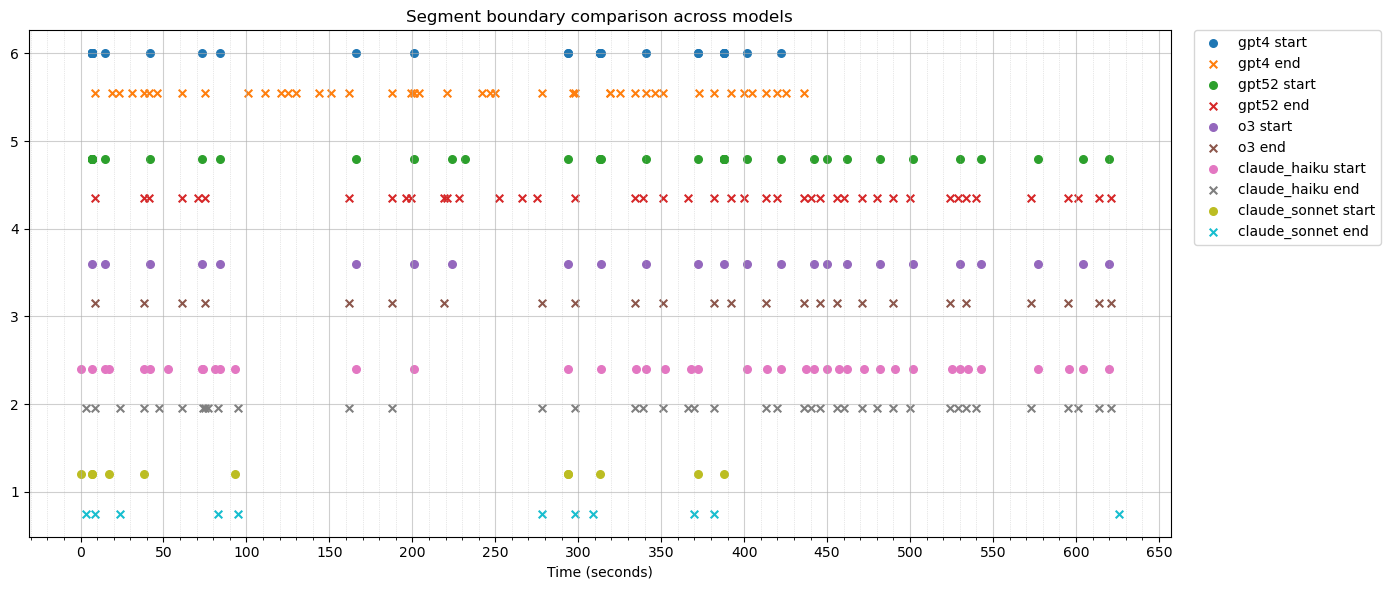

In [45]:
## Method4: Segment boundary alignment visualization (multi-model)
plt.figure(figsize=(14, 6))

model_order = list(boundary_data.keys())
if not model_order:
    raise ValueError("No model data loaded for visualization.")

row_gap = 1.2
for i, model_name in enumerate(model_order):
    y_start = (len(model_order) - i) * row_gap
    y_end = y_start - 0.45

    starts = boundary_data[model_name]["starts"]
    ends = boundary_data[model_name]["ends"]

    plt.scatter(starts, [y_start] * len(starts), s=30, label=f"{model_name} start")
    plt.scatter(ends, [y_end] * len(ends), s=30, marker="x", label=f"{model_name} end")

plt.xlabel("Time (seconds)")
plt.title("Segment boundary comparison across models")

from matplotlib.ticker import MultipleLocator
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(50))
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(which="major", linestyle="-", linewidth=0.8, alpha=0.6)
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.6)

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()